In [1]:
import numpy as np
import matplotlib.pyplot as plt
from safety_formation.control_law.cbf import CentralizedCBF

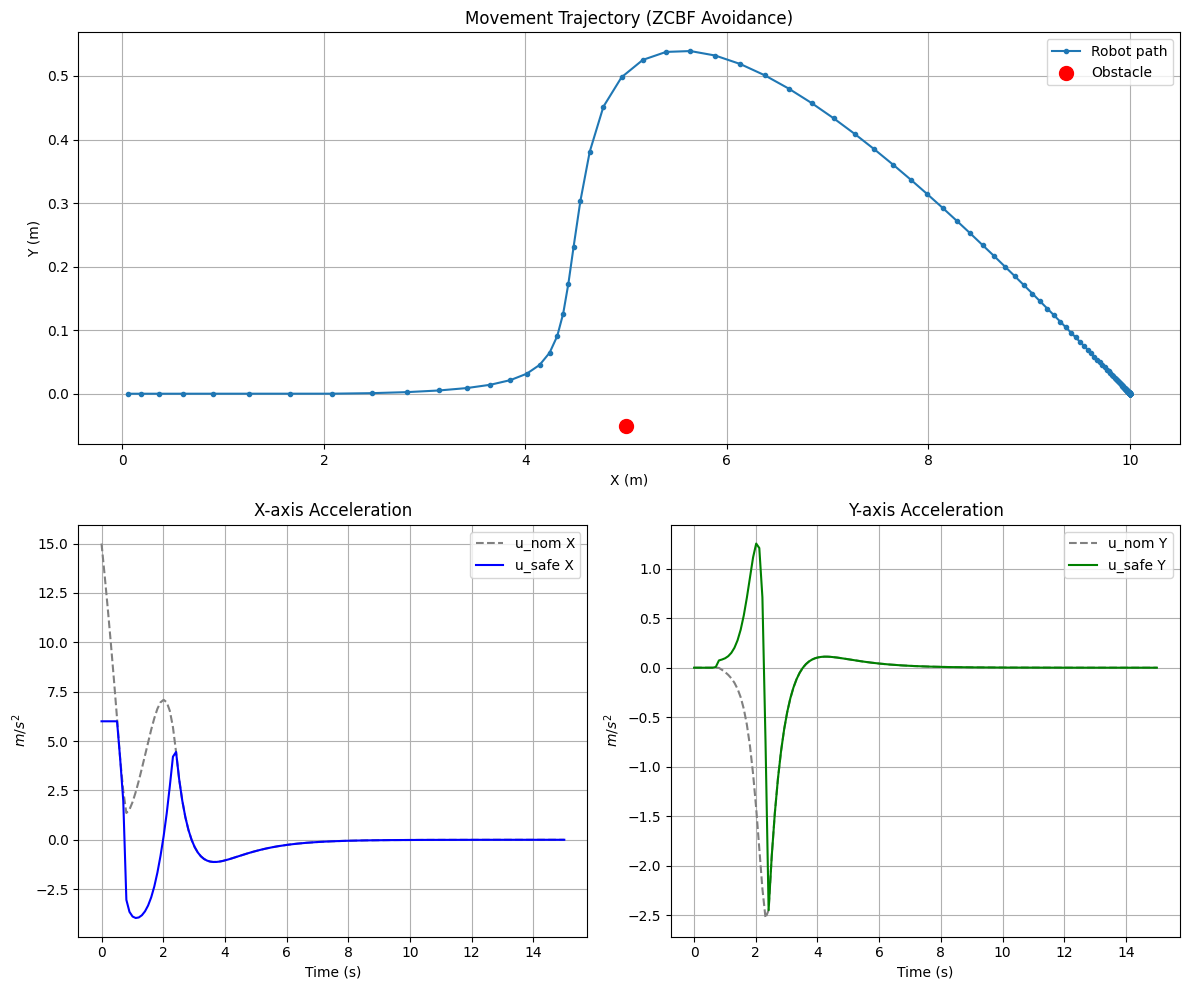

In [2]:
# --- Initialize parameters ---
dt = 0.1
T = 15.0 # Increased time to allow the robot to bypass the obstacle
steps = int(T / dt)
gamma = 1 # Increased gamma slightly for a smoother avoidance response
d_min = 0.5 

# State: [x, y, vx, vy]
x_agent = np.array([0.0, 0.0, 0.0, 0.0]) 
x_obs = np.array([5.0, -0.05, 0, 0.0]) 
x_target = np.array([10.0, 0.0, 0.0, 0.0])

alpha_agent = 6.0 # Max acceleration for robot
alpha_obs = 0.0   # Obstacle is static

history = []
u_hat_history = []
u_safe_history = []

# Instantiate the CBF filter
cbf_filter = CentralizedCBF(gamma=gamma, safety_dis=d_min)

for k in range(steps):
    # 1. Compute nominal control (u_nom)
    # Using x_agent[0:2] (current position) so the robot always faces the goal
    # This is a PD-like controller to track the target
    u_hat = -1.5 * (x_agent[0:2] - x_target[0:2]) - 2.5 * x_agent[2:4]
    
    # 2. Mock Data / Wrap objects for the CBF class
    class MockAgent:
        def __init__(self, state, alpha, id):
            self.state = state.reshape(4,1); self.alpha = alpha
            self.id = id; self.pos = state[0:2]; self.vel = state[2:4]
            self.gamma = gamma
    
    a1 = MockAgent(x_agent, alpha_agent, 1)
    a2 = MockAgent(x_obs, alpha_obs, 2)
    
    class MockTopo:
        adj_matrix = np.array([[0, 1], [1, 0]]) # Full connectivity between agent and obstacle
    
    # 3. Filter nominal control through CBF
    u_nom_all = np.array([u_hat, [0, 0]]) 
    u_safe_all = cbf_filter.compute_safe_control([a1, a2], MockTopo(), u_nom_all)
    
    # Apply safe control for the robot (index 0), or zero if solver fails
    if u_safe_all is not None:
        u_apply = u_safe_all[0]
    else:
        u_apply = np.array([0, 0])

    # Store control history for plotting
    u_hat_history.append(u_hat.copy())
    u_safe_history.append(u_apply.copy())

    # 4. Update Physics (Euler Integration)
    x_agent[2:4] += u_apply * dt    # Update velocity: v = v + a*dt
    x_agent[0:2] += x_agent[2:4] * dt # Update position: p = p + v*dt
    history.append(x_agent.copy())

# --- Convert data to Numpy arrays ---
history = np.array(history)
u_hat_history = np.array(u_hat_history)
u_safe_history = np.array(u_safe_history)
time = np.linspace(0, T, steps)

# --- PLOTTING ---
fig = plt.figure(figsize=(12, 10))

# 1. Movement Trajectory
ax1 = plt.subplot(2, 1, 1)
ax1.plot(history[:, 0], history[:, 1], '-o', markersize=3, label='Robot path')
ax1.scatter([5.0], [-0.05], color='red', s=100, label='Obstacle', zorder=5)
ax1.set_title("Movement Trajectory (ZCBF Avoidance)")
ax1.set_xlabel("X (m)"); ax1.set_ylabel("Y (m)")
ax1.legend(); ax1.grid(True)

# 2. Control Signal u_x (Acceleration in X)
ax2 = plt.subplot(2, 2, 3)
ax2.plot(time, u_hat_history[:, 0], '--', color='gray', label='u_nom X')
ax2.plot(time, u_safe_history[:, 0], '-', color='blue', label='u_safe X')
ax2.set_title("X-axis Acceleration")
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("$m/s^2$")
ax2.legend(); ax2.grid(True)

# 3. Control Signal u_y (Acceleration in Y)
ax3 = plt.subplot(2, 2, 4)
ax3.plot(time, u_hat_history[:, 1], '--', color='gray', label='u_nom Y')
ax3.plot(time, u_safe_history[:, 1], '-', color='green', label='u_safe Y')
ax3.set_title("Y-axis Acceleration")
ax3.set_xlabel("Time (s)"); ax3.set_ylabel("$m/s^2$")
ax3.legend(); ax3.grid(True)

plt.tight_layout()
plt.show()

QP Solver failed to find a solution!


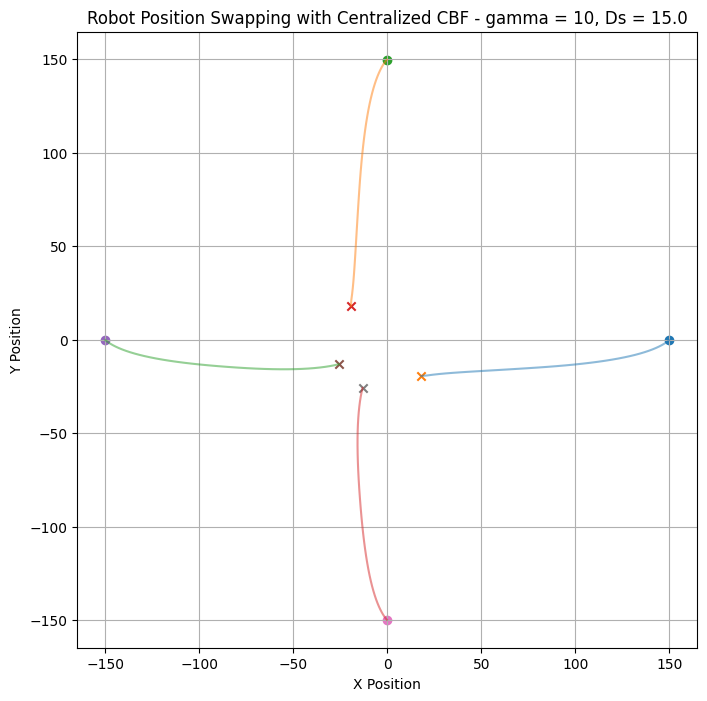

In [13]:
# --- Simulation Configuration ---
N = 4           
R_circle = 150   # Circle radius
dt = 0.1
T_max = 100
gamma = 0.1
d_min = 9.0      # Safety distance (Ds = 10)
k1, k2 = 1.0, 2.0 # PD controller gains (Proportional and Derivative)

# --- State Initialization ---
agents_list = []
class AgentObj:
    def __init__(self, id, pos, target):
        self.id = id
        self.pos = pos
        self.vel = np.zeros(2)
        self.target = target
        self.alpha = 20.0 # Maximum acceleration capability
        self.gamma = gamma

for i in range(N):
    # Calculate starting positions evenly spaced on the circle
    angle = 2 * np.pi * i / N
    # Initial position on the circle
    pos = np.array([R_circle * np.cos(angle), R_circle * np.sin(angle)])
    # Target position is on the opposite side of the circle (with a slight offset)
    target = -pos - 20
    agents_list.append(AgentObj(i, pos, target))

# Simulate Topology (Fully Connected - Every robot sees every other robot)
class FullTopology:
    # Adjacency matrix: 1 where connected, 0 on the diagonal (self-connection)
    adj_matrix = np.ones((N, N)) - np.eye(N)

cbf_filter = CentralizedCBF(gamma=gamma, safety_dis=d_min)

# --- Simulation Loop ---
# Store position history for each agent to plot trajectories later
history = [[] for _ in range(N)]

for t in range(int(T_max/dt)):
    # 1. Calculate nominal control (u_nom) for all N robots using PD Control
    u_nom_all = []
    for ag in agents_list:
        # PD Law: u = -k1*(pos_error) - k2*(velocity)
        u_i = -k1 * (ag.pos - ag.target) - k2 * ag.vel
        u_nom_all.append(u_i)
    u_nom_all = np.array(u_nom_all)

    # 2. Filter nominal controls through the Centralized CBF to ensure safety
    u_safe_all = cbf_filter.compute_safe_control(agents_list, FullTopology(), u_nom_all)
    
    # Exit loop if the QP solver fails to find a feasible solution
    if u_safe_all is None: break

    # 3. Update Physics (Euler Integration)
    for i, ag in enumerate(agents_list):
        ag.vel += u_safe_all[i] * dt  # Acceleration to Velocity
        ag.pos += ag.vel * dt        # Velocity to Position
        history[i].append(ag.pos.copy())

# --- Plot Trajectories (Visualizing results similar to Figure 3 in the paper) ---
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
for i in range(N):
    traj = np.array(history[i])
    plt.plot(traj[:,0], traj[:,1], alpha=0.5) # Draw the path
    plt.scatter(traj[0,0], traj[0,1], marker='o') # Start point marker
    plt.scatter(traj[-1,0], traj[-1,1], marker='x') # End point marker

plt.title("Robot Position Swapping with Centralized CBF - gamma = 10, Ds = 15.0")
plt.xlabel("X Position"); plt.ylabel("Y Position")
plt.grid(True)
plt.show()

In [9]:
from matplotlib.animation import FFMpegWriter, FuncAnimation

# --- Simulation Configuration ---
N = 3           # Number of robots (set to 20 as in the paper)
R_circle = 150   # Circle radius
dt = 0.1
T_max = 16
gamma = 10
d_min = 15.0      # Safety distance
k1, k2 = 1.0, 2.0 # PD controller gains

# 2. Define Class (Ensure float types are used)
class AgentObj:
    def __init__(self, id, pos, target):
        self.id = id
        self.pos = np.array(pos, dtype=float)
        self.vel = np.zeros(2, dtype=float)
        self.target = np.array(target, dtype=float)
        self.alpha = 20.0 # Maximum acceleration

# 3. RE-INITIALIZE STATE (Crucial step)
agents_list = []
history = [[] for _ in range(N)]

for i in range(N):
    angle = 2 * np.pi * i / N
    # Starting position on the circle
    pos = np.array([R_circle * np.cos(angle), R_circle * np.sin(angle)], dtype=float)
    # Target on the opposite side (Position Swap)
    target = -pos - 10
    agents_list.append(AgentObj(i, pos, target))

# 4. Set up Figure for Animation
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-R_circle - 50, R_circle + 50)
ax.set_ylim(-R_circle - 50, R_circle + 50)
ax.set_aspect("equal")
ax.grid(True)
ax.set_title("Robot Swapping - Centralized CBF Simulation - gamma = 10, Ds = 15.0")

# Plot targets (Red X marks)
for ag in agents_list:
    ax.scatter(ag.target[0], ag.target[1], marker="x", color="red", s=100)

# Initialize graphic objects
points = [ax.plot([], [], "o", ms=10)[0] for _ in range(N)]
trails = [ax.plot([], [], alpha=0.3, lw=1.5)[0] for _ in range(N)]
info_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

# 5. Update function for each frame
def update(frame):
    global agents_list, history
    
    # Calculate nominal control (u_nom)
    u_nom_all = []
    for ag in agents_list:
        u_i = -k1 * (ag.pos - ag.target) - k2 * ag.vel
        u_nom_all.append(u_i)
    u_nom_all = np.array(u_nom_all)

    # Calculate CBF (Using your filter)
    u_safe_all = cbf_filter.compute_safe_control(agents_list, FullTopology(), u_nom_all)
    # u_safe_all = u_nom_all # Temporary: use u_nom to test basic movement

    # Physics Update (Euler Integration)
    for i in range(N):
        agents_list[i].vel += u_safe_all[i] * dt
        agents_list[i].pos += agents_list[i].vel * dt
        
        # Update plot data
        history[i].append(agents_list[i].pos.copy())
        traj = np.array(history[i])
        
        # Update point positions and trails
        points[i].set_data([agents_list[i].pos[0]], [agents_list[i].pos[1]])
        trails[i].set_data(traj[:, 0], traj[:, 1])

    # Log debug info every 50 frames
    if frame % 50 == 0:
        print(f"Frame {frame}: Agent 0 is at {agents_list[0].pos}")

    info_text.set_text(f"Time: {frame*dt:.1f}s")
    return points + trails + [info_text]

# 6. Proceed to Render and Save file
print("Starting MP4 video save process...")
total_frames = int(T_max / dt)
ani = FuncAnimation(fig, update, frames=total_frames, blit=True)

# Writer configuration (Requires ffmpeg installed)
try:
    writer = FFMpegWriter(fps=int(1/dt), bitrate=2000)
    ani.save("centralized_cbf_validation.mp4", writer=writer)
    print("Done! File 'centralized_cbf_validation.mp4' has been created.")
except Exception as e:
    print(f"Error while saving video: {e}")

plt.close(fig)

Starting MP4 video save process...
Frame 0: Agent 0 is at [ 1.498e+02 -1.000e-01]
Frame 0: Agent 0 is at [149.4    -0.279]
Frame 0: Agent 0 is at [148.8      -0.51941]
Frame 0: Agent 0 is at [148.         -0.8065439]
Frame 50: Agent 0 is at [  9.58577759 -14.67641676]
Frame 100: Agent 0 is at [-151.56814954  -10.20676937]
Frame 150: Agent 0 is at [-159.80649674  -10.00473938]
Done! File 'centralized_cbf_validation.mp4' has been created.
